In [1]:
from pathlib import Path
OUTPUT_DIR = Path('/Users/fteodoro/Dropbox/Doutorado/Tese/figuras')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Rectangle
import numpy as np

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

Saved: /Users/fteodoro/Dropbox/Doutorado/Tese/figuras/fig_pkfold_walkforward.pdf


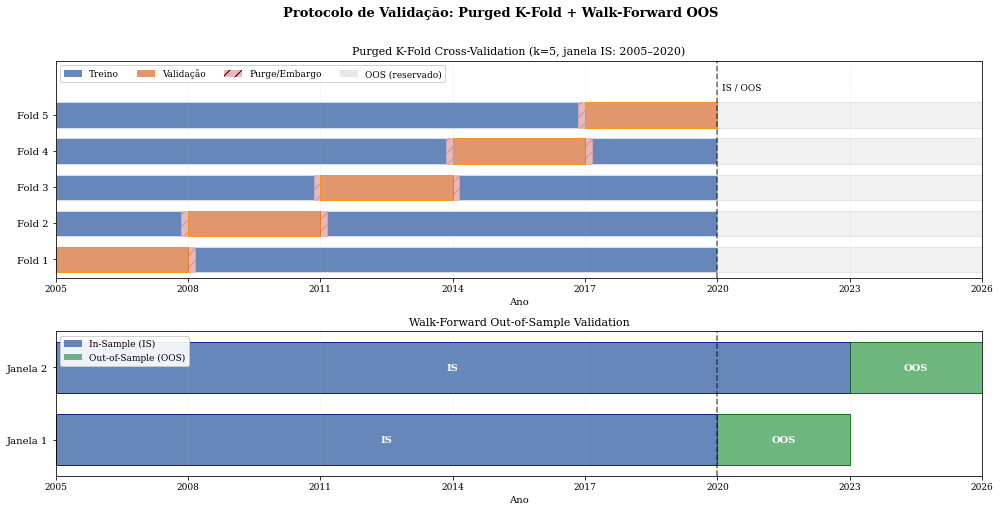

In [3]:
# Timeline parameters
T_START = 2005
T_END   = 2026
T_SPLIT = 2020          # IS / OOS split
T_RANGE = T_END - T_START

# Purged K-Fold: 5 splits over [2005, 2020]
K = 5
is_start = T_START
is_end   = T_SPLIT
is_len   = is_end - is_start
fold_len = is_len / K          # width of each fold in years
purge_w  = 0.15                # purge/embargo width in years

# Walk-Forward: 2 windows over full range
wf_windows = [
    {'is': (2005, 2020), 'oos': (2020, 2023)},
    {'is': (2005, 2023), 'oos': (2023, 2026)},
]

fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                         gridspec_kw={'height_ratios': [3, 2]})
fig.suptitle('Protocolo de Validação: Purged K-Fold + Walk-Forward OOS',
             fontsize=13, fontweight='bold', y=1.01)

# ── TOP: Purged K-Fold ──────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(T_START, T_END)
ax.set_ylim(-0.5, K + 0.5)
ax.set_yticks(range(K))
ax.set_yticklabels([f'Fold {k+1}' for k in range(K)])
ax.set_xlabel('Ano')
ax.set_title('Purged K-Fold Cross-Validation (k=5, janela IS: 2005–2020)', fontsize=11)
ax.axvline(T_SPLIT, color='black', lw=1.5, ls='--', alpha=0.6)
ax.text(T_SPLIT + 0.1, K - 0.1, 'IS / OOS', fontsize=9, color='black', va='top')

colors_train = '#4C72B0'
colors_val   = '#DD8452'
colors_purge = '#C44E52'

for k in range(K):
    val_start = is_start + k * fold_len
    val_end   = val_start + fold_len

    # Train: all IS except validation fold (and purge zones)
    # Left train block
    if val_start - purge_w > is_start:
        rect = Rectangle((is_start, k - 0.35),
                          val_start - purge_w - is_start, 0.7,
                          linewidth=0.5, edgecolor='white',
                          facecolor=colors_train, alpha=0.85)
        ax.add_patch(rect)

    # Right train block
    right_start = val_end + purge_w
    if right_start < is_end:
        rect = Rectangle((right_start, k - 0.35),
                          is_end - right_start, 0.7,
                          linewidth=0.5, edgecolor='white',
                          facecolor=colors_train, alpha=0.85)
        ax.add_patch(rect)

    # Purge/embargo left
    if val_start - purge_w >= is_start:
        rect = Rectangle((val_start - purge_w, k - 0.35),
                          purge_w, 0.7,
                          linewidth=0.5, edgecolor=colors_purge,
                          facecolor=colors_purge, alpha=0.4,
                          hatch='//')
        ax.add_patch(rect)

    # Validation fold
    rect = Rectangle((val_start, k - 0.35),
                      fold_len, 0.7,
                      linewidth=1.0, edgecolor='darkorange',
                      facecolor=colors_val, alpha=0.85)
    ax.add_patch(rect)

    # Purge/embargo right
    if val_end + purge_w <= is_end:
        rect = Rectangle((val_end, k - 0.35),
                          purge_w, 0.7,
                          linewidth=0.5, edgecolor=colors_purge,
                          facecolor=colors_purge, alpha=0.4,
                          hatch='//')
        ax.add_patch(rect)

    # OOS region (greyed out)
    rect = Rectangle((T_SPLIT, k - 0.35),
                      T_END - T_SPLIT, 0.7,
                      linewidth=0.5, edgecolor='grey',
                      facecolor='lightgrey', alpha=0.3)
    ax.add_patch(rect)

legend_elements = [
    mpatches.Patch(facecolor=colors_train, alpha=0.85, label='Treino'),
    mpatches.Patch(facecolor=colors_val,   alpha=0.85, label='Validação'),
    mpatches.Patch(facecolor=colors_purge, alpha=0.4,
                   hatch='//', label='Purge/Embargo'),
    mpatches.Patch(facecolor='lightgrey',  alpha=0.5,  label='OOS (reservado)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          ncol=4, framealpha=0.9)

xticks = list(range(T_START, T_END + 1, 3))
ax.set_xticks(xticks)
ax.set_xticklabels([str(y) for y in xticks], fontsize=9)
ax.grid(axis='x', alpha=0.3, ls=':')

# ── BOTTOM: Walk-Forward OOS ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(T_START, T_END)
ax2.set_ylim(-0.5, len(wf_windows) - 0.5)
ax2.set_yticks(range(len(wf_windows)))
ax2.set_yticklabels([f'Janela {i+1}' for i in range(len(wf_windows))])
ax2.set_xlabel('Ano')
ax2.set_title('Walk-Forward Out-of-Sample Validation', fontsize=11)
ax2.axvline(T_SPLIT, color='black', lw=1.5, ls='--', alpha=0.6)

for i, wf in enumerate(wf_windows):
    is_s, is_e = wf['is']
    oo_s, oo_e = wf['oos']

    rect_is = Rectangle((is_s, i - 0.35), is_e - is_s, 0.7,
                         linewidth=1.0, edgecolor='navy',
                         facecolor='#4C72B0', alpha=0.85)
    ax2.add_patch(rect_is)
    ax2.text((is_s + is_e) / 2, i, 'IS', ha='center', va='center',
             color='white', fontweight='bold', fontsize=10)

    rect_oos = Rectangle((oo_s, i - 0.35), oo_e - oo_s, 0.7,
                          linewidth=1.0, edgecolor='darkgreen',
                          facecolor='#55A868', alpha=0.85)
    ax2.add_patch(rect_oos)
    ax2.text((oo_s + oo_e) / 2, i, 'OOS', ha='center', va='center',
             color='white', fontweight='bold', fontsize=10)

legend2 = [
    mpatches.Patch(facecolor='#4C72B0', alpha=0.85, label='In-Sample (IS)'),
    mpatches.Patch(facecolor='#55A868', alpha=0.85, label='Out-of-Sample (OOS)'),
]
ax2.legend(handles=legend2, loc='upper left', fontsize=9, framealpha=0.9)
ax2.set_xticks(xticks)
ax2.set_xticklabels([str(y) for y in xticks], fontsize=9)
ax2.grid(axis='x', alpha=0.3, ls=':')

fig.tight_layout()
out_path = OUTPUT_DIR / 'fig_pkfold_walkforward.pdf'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()